# StockSight - 01 · Exploratory Data Analysis

Single-name deep dive on **AAPL** (a familiar large-cap used purely to illustrate the
data-understanding methodology). Price + macro data come from the same `src/` pipeline that
feeds the models; the modeled universe is the 21 tickers in `config.yaml`.

**Flow:** load → quality checks (missing / duplicates / outliers) → descriptive stats →
univariate / bivariate / multivariate analysis → technical-indicator panels → takeaways.

In [1]:
# === Setup (shared across the StockSight notebook suite) ===
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Locate the project root (the folder that holds config.yaml) and put it on sys.path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110})
sns.set_style("whitegrid")
sns.set_palette("deep")
HEATMAP_CMAP = "RdBu_r"
SEED = 42

from src.config import RESULTS_DIR, MODELS_DIR, CFG

print("Project root :", ROOT)
print("Universe     :", len(CFG["tickers"]), "tickers ->", ", ".join(CFG["tickers"]))

Project root : F:\AIProjects\stocksight
Universe     : 21 tickers -> NDSN, HON, BKR, APA, CSX, JBHT, FAST, FELE, GT, FITB, NTRS, EA, AEP, AMGN, COST, ROST, PEP, KMB, MAT, HAS, NWL


## 1 · Data loading
Stock OHLCV via the cached yfinance loader; macro changes (VIX, 10Y yield, oil, USD) via `build_macro_df()`.

In [2]:
from src.data_loader import load_stock, load_all_macro
from src.preprocessing import build_macro_df

TICKER = "AAPL"
try:
    stock = load_stock(TICKER)
except Exception as exc:
    TICKER = "COST"
    stock = load_stock(TICKER)
    print(f"(AAPL fetch failed: {exc}; using {TICKER} instead)")

stock = stock.sort_values("date").reset_index(drop=True)
macro_df = build_macro_df()   # date, vix_change, tnx_change, oil_change, usd_change

print(f"{TICKER}: {stock.shape[0]} rows  {stock['date'].min().date()} -> {stock['date'].max().date()}")
print("macro:", macro_df.shape)
stock.head()

AAPL: 9171 rows  1990-01-02 -> 2026-06-02
macro: (9173, 5)


,date,close,high,low,open,volume
0,1990-01-02,0.260465,0.262213,0.244733,0.246481,183198400
1,1990-01-03,0.262213,0.265710,0.262213,0.265710,207995200
2,1990-01-04,0.263088,0.270954,0.260465,0.267458,221513600
3,1990-01-05,0.263962,0.267458,0.258717,0.263962,123312000
4,1990-01-08,0.265710,0.265710,0.258717,0.262213,101572800


## 2 · Feature engineering (inline)
We build the same technical + macro features the models use, by calling the public helpers in
`src.features` directly. (We skip the sector-correlation branch because AAPL has no sector mapping;
it would otherwise raise `KeyError`.) `LogVolume = log1p(volume)` tames the right-skewed volume.

In [3]:
from src.features import (add_returns, add_lag_features, add_moving_averages,
                          add_rsi, add_macd, add_volatility, add_bollinger_bands,
                          add_volume_ratio, add_macro_features,
                          FEATURE_COLUMNS_BASE, MACRO_COLUMNS)

df = stock.copy()
df = add_returns(df)
df = add_lag_features(df)
df = add_moving_averages(df)
df = add_rsi(df, period=14)
df = add_macd(df)
df = add_volatility(df, window=21)
df = add_bollinger_bands(df)
df = add_volume_ratio(df)
df = add_macro_features(df, macro_df)
df["LogVolume"] = np.log1p(df["volume"])

print("shape:", df.shape)
print("feature base:", FEATURE_COLUMNS_BASE)
print("macro cols  :", MACRO_COLUMNS)
df[["date", "close", "returns", "log_returns", "rsi_14", "macd", "volatility_21"]].tail()

shape: (9171, 25)
feature base: ['close', 'returns', 'log_returns', 'close_pct_lag_1', 'close_pct_lag_5', 'ma_5', 'ma_20', 'ema_12', 'ema_26', 'rsi_14', 'macd', 'macd_signal', 'volatility_21', 'bb_width', 'volume_ratio']
macro cols  : ['vix_change', 'tnx_change', 'oil_change', 'usd_change']


,date,close,returns,log_returns,rsi_14,macd,volatility_21
9166,2026-05-27,310.850006,0.008173,0.008140,87.390930,10.334335,0.010733
9167,2026-05-28,312.510010,0.005340,0.005326,88.206614,10.487955,0.010694
9168,2026-05-29,312.059998,-0.001440,-0.001441,84.276754,10.452893,0.010671
9169,2026-06-01,306.309998,-0.018426,-0.018598,70.582846,9.847613,0.012024
9170,2026-06-02,315.200012,0.029023,0.028610,75.576679,9.970341,0.011670


## 3 · Missing values
Rolling windows (MA, RSI, volatility) create NaNs at the head; we report and drop them.

In [4]:
miss = df.isna().sum()
display(miss[miss > 0].sort_values(ascending=False).to_frame("n_missing"))

before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"dropped {before - len(df)} rows with NaNs -> {len(df)} clean rows")

,n_missing
oil_change,2700
tnx_change,31
volatility_21,21
bb_width,19
ma_20,19
volume_ratio,19
rsi_14,13
close_pct_lag_5,5
ma_5,4
returns,1


dropped 2720 rows with NaNs -> 6451 clean rows


## 4 · Duplicates
No duplicated rows or repeated trading dates expected in a clean daily series.

In [5]:
print("duplicated rows :", int(df.duplicated().sum()))
print("duplicated dates:", int(df['date'].duplicated().sum()))

duplicated rows : 0
duplicated dates: 0


## 5 · Outliers (IQR rule)
Raw `volume` is heavily right-skewed and flags many "outliers"; the log transform compresses the
tail so it behaves like a usable feature. We inspect `close`, `volume`, `LogVolume`.

close     :  914 outliers (14.2%)
volume    :  358 outliers ( 5.5%)
LogVolume :   18 outliers ( 0.3%)


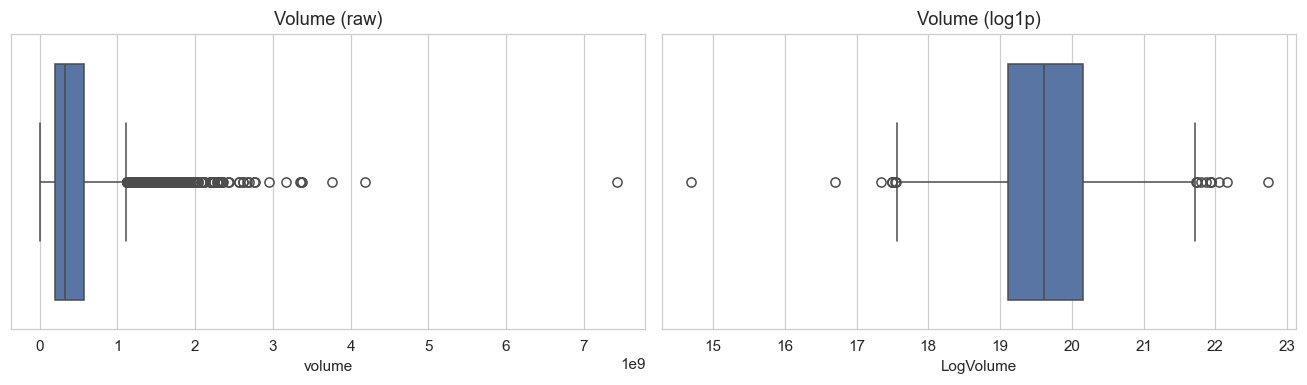

In [6]:
def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    mask = (s < lo) | (s > hi)
    return int(mask.sum()), float(mask.mean() * 100)

for col in ["close", "volume", "LogVolume"]:
    n, pct = iqr_outliers(df[col])
    print(f"{col:10s}: {n:4d} outliers ({pct:4.1f}%)")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
sns.boxplot(x=df["volume"], ax=ax[0]);    ax[0].set_title("Volume (raw)")
sns.boxplot(x=df["LogVolume"], ax=ax[1]); ax[1].set_title("Volume (log1p)")
plt.tight_layout(); plt.show()

## 6 · Uniqueness
Sanity check on cardinality - price/volume columns are near-continuous.

In [7]:
df.drop(columns=['date']).nunique().sort_values().to_frame('n_unique')

,n_unique
close,5004
tnx_change,6151
log_returns,6221
close_pct_lag_1,6221
returns,6221
low,6235
usd_change,6272
high,6276
volume,6309
LogVolume,6309


## 7 · Descriptive statistics

In [8]:
num = df.select_dtypes("number")
desc = num.describe().T
desc["median"] = num.median()
desc[["mean", "median", "std", "min", "25%", "50%", "75%", "max"]].round(4)

,mean,median,std,min,25%,50%,75%,max
close,4.297900e+00,4.363000e-01,6.884500e+00,9.680000e-02,2.783000e-01,4.363000e-01,5.172200e+00,2.956730e+01
high,4.345100e+00,4.444000e-01,6.948400e+00,9.920000e-02,2.842000e-01,4.444000e-01,5.255200e+00,2.988860e+01
low,4.249600e+00,4.295000e-01,6.821100e+00,9.540000e-02,2.719000e-01,4.295000e-01,5.089200e+00,2.931300e+01
open,4.300300e+00,4.367000e-01,6.889400e+00,9.640000e-02,2.782000e-01,4.367000e-01,5.177900e+00,2.987080e+01
volume,4.455656e+08,3.312372e+08,3.794071e+08,2.396800e+06,2.005080e+08,3.312372e+08,5.671414e+08,7.421641e+09
returns,1.200000e-03,0.000000e+00,2.930000e-02,-5.187000e-01,-1.370000e-02,0.000000e+00,1.530000e-02,3.323000e-01
log_returns,7.000000e-04,0.000000e+00,2.990000e-02,-7.312000e-01,-1.380000e-02,0.000000e+00,1.520000e-02,2.869000e-01
close_pct_lag_1,1.200000e-03,0.000000e+00,2.930000e-02,-5.187000e-01,-1.370000e-02,0.000000e+00,1.530000e-02,3.323000e-01
close_pct_lag_5,5.800000e-03,5.500000e-03,6.470000e-02,-5.876000e-01,-2.980000e-02,5.500000e-03,4.070000e-02,6.679000e-01
ma_5,4.290300e+00,4.360000e-01,6.874400e+00,9.830000e-02,2.779000e-01,4.360000e-01,5.164500e+00,2.932950e+01


## 8 · Univariate distributions
- `close`: right-skewed - long-run uptrend.
- `LogVolume`: roughly bell-shaped after the log transform.
- `log_returns`: near-symmetric around 0 with fat tails (high kurtosis) - the classic return signature.

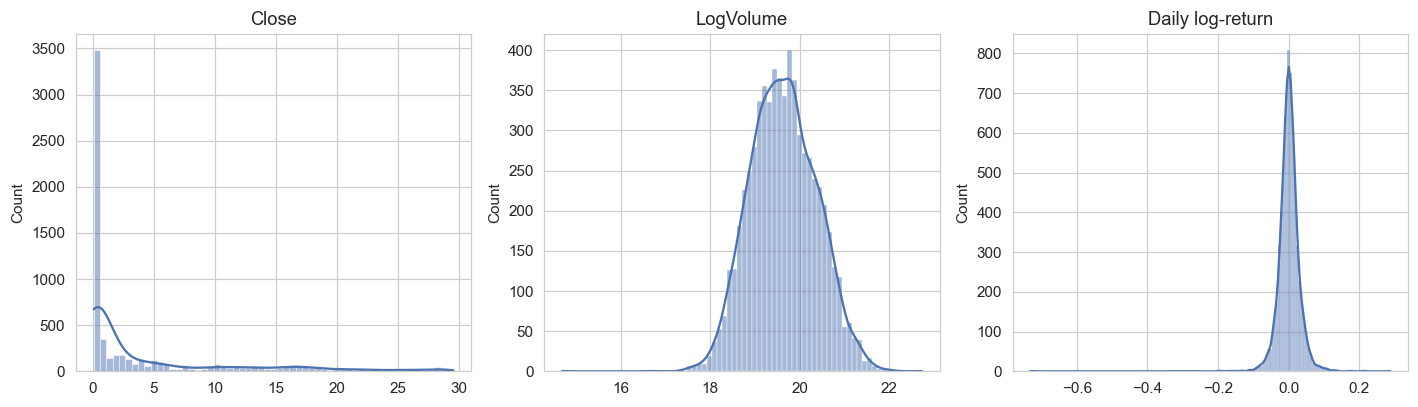

close      skew=+1.89
LogVolume  skew=+0.07
log_return skew=-2.19  kurtosis=+61.12


In [9]:
from scipy import stats

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
sns.histplot(df["close"], kde=True, ax=ax[0]); ax[0].set_title("Close")
sns.histplot(df["LogVolume"], kde=True, ax=ax[1]); ax[1].set_title("LogVolume")
sns.histplot(df["log_returns"], kde=True, ax=ax[2]); ax[2].set_title("Daily log-return")
for a in ax:
    a.set_xlabel("")
plt.tight_layout(); plt.show()

print(f"close      skew={stats.skew(df['close']):+.2f}")
print(f"LogVolume  skew={stats.skew(df['LogVolume']):+.2f}")
print(f"log_return skew={stats.skew(df['log_returns']):+.2f}  kurtosis={stats.kurtosis(df['log_returns']):+.2f}")

## 9 · Bivariate relationships
Daily return vs macro changes. Returns tend to fan out (higher dispersion) when VIX moves a lot -
a non-linear pattern that motivates tree-based and sequence models over a plain linear fit.

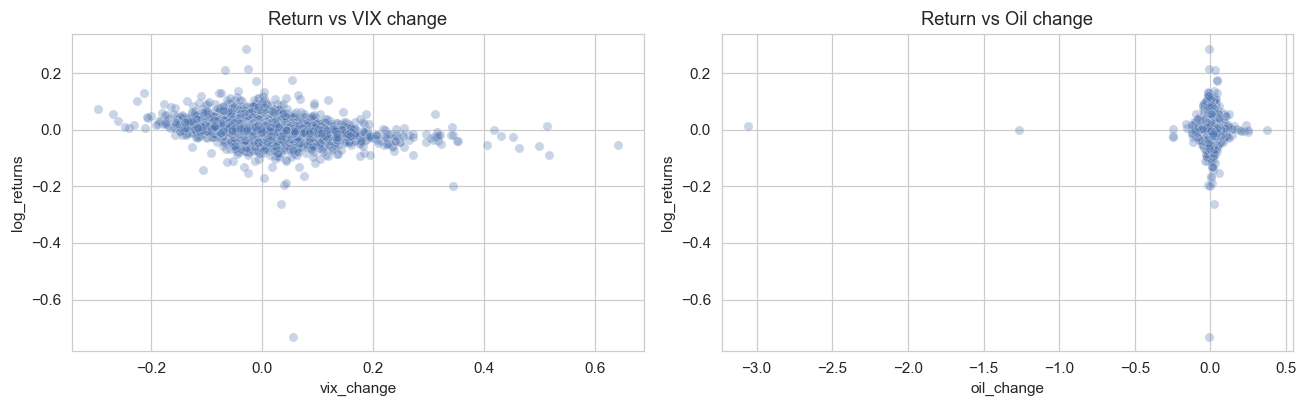

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
sns.scatterplot(x=df["vix_change"], y=df["log_returns"], alpha=0.3, ax=ax[0])
ax[0].set_title("Return vs VIX change")
sns.scatterplot(x=df["oil_change"], y=df["log_returns"], alpha=0.3, ax=ax[1])
ax[1].set_title("Return vs Oil change")
plt.tight_layout(); plt.show()

## 10 · Multivariate - correlation matrix
Returns, macro changes and key technicals. Diverging `RdBu_r` centred at 0. No pair sits near the
±0.85 collinearity danger zone, so the engineered features carry largely complementary information.

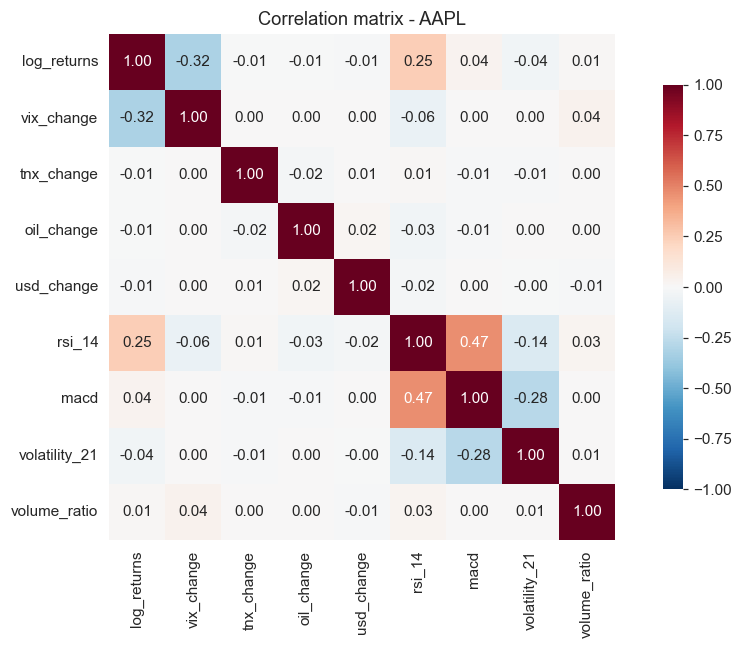

In [11]:
corr_cols = ["log_returns", "vix_change", "tnx_change", "oil_change", "usd_change",
             "rsi_14", "macd", "volatility_21", "volume_ratio"]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=HEATMAP_CMAP, center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title(f"Correlation matrix - {TICKER}")
plt.tight_layout(); plt.show()

## 11 · Technical-indicator panels
Presentation-friendly views of the indicators the models consume.

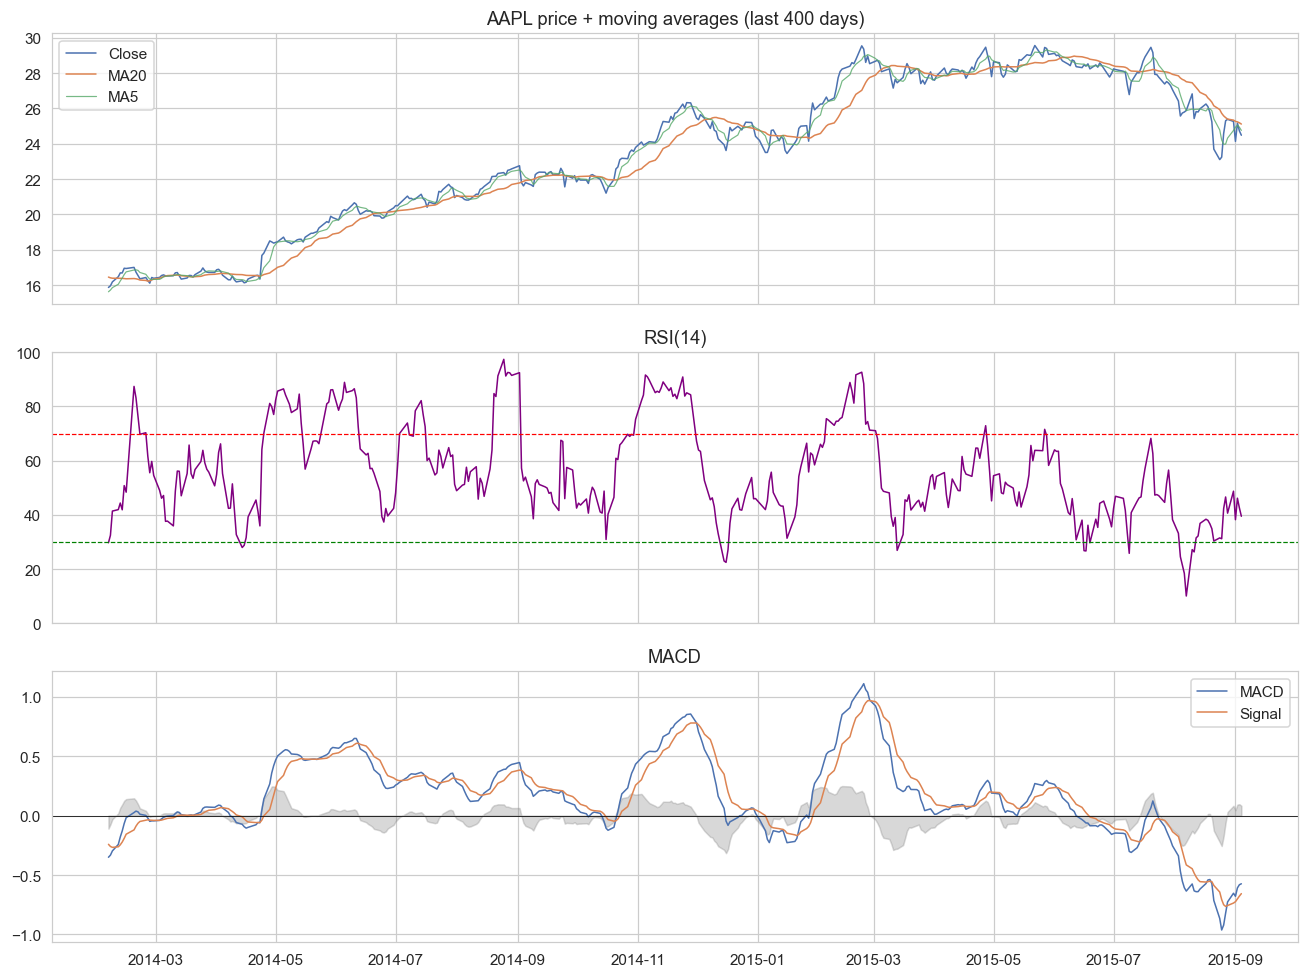

In [12]:
recent = df.tail(400)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(recent["date"], recent["close"], lw=1, label="Close")
axes[0].plot(recent["date"], recent["ma_20"], lw=1, label="MA20")
axes[0].plot(recent["date"], recent["ma_5"], lw=0.8, alpha=0.8, label="MA5")
axes[0].set_title(f"{TICKER} price + moving averages (last 400 days)"); axes[0].legend()

axes[1].plot(recent["date"], recent["rsi_14"], color="purple", lw=1)
axes[1].axhline(70, color="red", ls="--", lw=0.8); axes[1].axhline(30, color="green", ls="--", lw=0.8)
axes[1].set_ylim(0, 100); axes[1].set_title("RSI(14)")

axes[2].plot(recent["date"], recent["macd"], label="MACD", lw=1)
axes[2].plot(recent["date"], recent["macd_signal"], label="Signal", lw=1)
axes[2].axhline(0, color="black", lw=0.5)
axes[2].fill_between(recent["date"], recent["macd"] - recent["macd_signal"], 0,
                     alpha=0.3, color="gray")
axes[2].set_title("MACD"); axes[2].legend()
plt.tight_layout(); plt.show()

## 12 · Takeaways → modeling

- **Target.** Models predict the **1-day forward return** (`make_targets` → `y_return`); the DL
  model predicts a **14-day return sequence**.
- **Features.** ~18 technicals + 4 macro changes (+ sector-correlation features for universe tickers).
  Scaled with `MinMaxScaler` fit on train only.
- **Split.** Chronological **85 / 15** train/test, with the last 10% of train held out for validation.
- **Why non-linear models.** Return-vs-VIX fan-out and fat-tailed returns argue for RF/XGB and the
  CNN+BiLSTM+Attention sequence model.

Next: **`02_ml_results`** (classical ML), **`03_dl`** (deep learning), **`04_evaluation`** (metrics + backtest).